In [1]:
# Library to suppress warnings or deprecation notes
import warnings

warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data

import pandas as pd
import numpy as np

# Library to split data
from sklearn.model_selection import train_test_split

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# Libraries to build decision tree classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To tune different models
from sklearn.model_selection import GridSearchCV

# To perform statistical analysis
import scipy.stats as stats

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    make_scorer,
)

In [2]:
data = pd.read_csv('/content/INNHotelsGroup.csv')

In [3]:
data.head()


,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224.0,2017.0,10.0,2.0,Offline,0.0,0.0,0.0,65.00,0.0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5.0,2018.0,11.0,6.0,Online,0.0,0.0,0.0,106.68,1.0,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1.0,2018.0,2.0,28.0,Online,0.0,0.0,0.0,60.00,0.0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211.0,2018.0,5.0,20.0,Online,0.0,0.0,0.0,100.00,0.0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48.0,2018.0,4.0,11.0,Online,0.0,0.0,0.0,94.50,0.0,Canceled


In [4]:
data.shape

(23474, 19)

data has 36275 rows and 19 columns

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23474 entries, 0 to 23473
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            23474 non-null  object 
 1   no_of_adults                          23474 non-null  int64  
 2   no_of_children                        23474 non-null  int64  
 3   no_of_weekend_nights                  23474 non-null  int64  
 4   no_of_week_nights                     23474 non-null  int64  
 5   type_of_meal_plan                     23474 non-null  object 
 6   required_car_parking_space            23474 non-null  int64  
 7   room_type_reserved                    23474 non-null  object 
 8   lead_time                             23473 non-null  float64
 9   arrival_year                          23473 non-null  float64
 10  arrival_month                         23473 non-null  float64
 11  arrival_date   

**Observation:**
data has 5 object type variable include target variable

avg_price_per_room is only float type

13 independent variables are type integer



In [6]:
data.describe(include='all')

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
count,23474,23474.000000,23474.000000,23474.000000,23474.000000,23474,23474.000000,23474,23473.000000,23473.000000,23473.000000,23473.000000,23473,23473.000000,23473.000000,23473.000000,23473.000000,23473.000000,23473
unique,23474,NaN,NaN,NaN,NaN,4,NaN,7,NaN,NaN,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,2
top,INN23474,NaN,NaN,NaN,NaN,Meal Plan 1,NaN,Room_Type 1,NaN,NaN,NaN,NaN,Online,NaN,NaN,NaN,NaN,NaN,Not_Canceled
freq,1,NaN,NaN,NaN,NaN,17945,NaN,18165,NaN,NaN,NaN,NaN,15423,NaN,NaN,NaN,NaN,NaN,15817
mean,NaN,1.848471,0.104712,0.813879,2.205973,NaN,0.031695,NaN,85.304350,2017.822818,7.432113,15.575214,NaN,0.025732,0.022111,0.156904,103.593484,0.626294,NaN
std,NaN,0.517244,0.405024,0.872375,1.413779,NaN,0.175190,NaN,86.039443,0.381831,3.062670,8.732694,NaN,0.158337,0.344986,1.793169,34.980419,0.788083,NaN
min,NaN,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,NaN,0.000000,2017.000000,1.000000,1.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,2.000000,0.000000,0.000000,1.000000,NaN,0.000000,NaN,17.000000,2018.000000,5.000000,8.000000,NaN,0.000000,0.000000,0.000000,80.750000,0.000000,NaN
50%,NaN,2.000000,0.000000,1.000000,2.000000,NaN,0.000000,NaN,57.000000,2018.000000,8.000000,16.000000,NaN,0.000000,0.000000,0.000000,99.900000,0.000000,NaN
75%,NaN,2.000000,0.000000,2.000000,3.000000,NaN,0.000000,NaN,126.000000,2018.000000,10.000000,23.000000,NaN,0.000000,0.000000,0.000000,120.150000,1.000000,NaN


**observation:**

1.Most customers prefer Meal Plan 1.

2.The most commonly reserved room type is Room Type 1.

3.The most common market segment is Online.

4.The majority of bookings have a status of Not_Canceled (target variable).











In [7]:
data['Booking_ID'].nunique()

23474

Since all the values in ID column are unique we can drop it

In [8]:
data['arrival_datetime'] = pd.to_datetime(data[['arrival_year', 'arrival_month', 'arrival_date']].rename(columns={'arrival_year': 'year', 'arrival_month': 'month', 'arrival_date': 'day'}), errors='coerce')

In [9]:
data.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,arrival_datetime
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224.0,2017.0,10.0,2.0,Offline,0.0,0.0,0.0,65.00,0.0,Not_Canceled,2017-10-02
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5.0,2018.0,11.0,6.0,Online,0.0,0.0,0.0,106.68,1.0,Not_Canceled,2018-11-06
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1.0,2018.0,2.0,28.0,Online,0.0,0.0,0.0,60.00,0.0,Canceled,2018-02-28
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211.0,2018.0,5.0,20.0,Online,0.0,0.0,0.0,100.00,0.0,Canceled,2018-05-20
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48.0,2018.0,4.0,11.0,Online,0.0,0.0,0.0,94.50,0.0,Canceled,2018-04-11


# **Cheking Missing Values**

In [10]:
data.isnull().sum()

,0
Booking_ID,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,1
arrival_year,1


In [11]:
data[data['arrival_datetime'].isna()]

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,arrival_datetime
2626,INN02627,2,0,1,5,Meal Plan 1,0,Room_Type 1,104.0,2018.0,2.0,29.0,Online,1.0,1.0,0.0,61.43,0.0,Canceled,NaT
3677,INN03678,1,0,1,3,Meal Plan 1,0,Room_Type 1,21.0,2018.0,2.0,29.0,Online,0.0,0.0,0.0,102.05,0.0,Canceled,NaT
5600,INN05601,2,0,1,3,Meal Plan 1,0,Room_Type 1,24.0,2018.0,2.0,29.0,Offline,0.0,0.0,0.0,45.50,0.0,Not_Canceled,NaT
6343,INN06344,1,0,1,1,Meal Plan 1,0,Room_Type 1,117.0,2018.0,2.0,29.0,Offline,0.0,0.0,0.0,76.00,0.0,Not_Canceled,NaT
7648,INN07649,2,1,1,5,Meal Plan 1,0,Room_Type 1,35.0,2018.0,2.0,29.0,Online,0.0,0.0,0.0,98.10,1.0,Canceled,NaT
8000,INN08001,2,2,1,3,Meal Plan 1,0,Room_Type 6,3.0,2018.0,2.0,29.0,Online,0.0,0.0,0.0,183.00,1.0,Not_Canceled,NaT
8989,INN08990,1,0,1,2,Meal Plan 1,0,Room_Type 1,117.0,2018.0,2.0,29.0,Offline,0.0,0.0,0.0,76.00,0.0,Not_Canceled,NaT
9153,INN09154,2,2,1,3,Meal Plan 1,0,Room_Type 6,3.0,2018.0,2.0,29.0,Online,0.0,0.0,0.0,189.75,0.0,Not_Canceled,NaT
9245,INN09246,2,0,1,3,Meal Plan 1,0,Room_Type 4,15.0,2018.0,2.0,29.0,Online,0.0,0.0,0.0,85.55,1.0,Not_Canceled,NaT
9664,INN09665,1,0,1,0,Meal Plan 1,0,Room_Type 4,21.0,2018.0,2.0,29.0,Online,0.0,0.0,0.0,117.00,0.0,Not_Canceled,NaT


The `NaT` values in `arrival_datetime` likely occurred because some dates, such as February 29th, do not exist in non-leap years (e.g., 2018 or 2017). I will replace these invalid dates with February 28th of the respective year.

In [12]:
data.drop(data[data['arrival_datetime'].isna()].index, inplace=True)

In [13]:

import calendar
from typing import Optional

def fix_invalid_feb29(
    df: pd.DataFrame,
    year_col: str = 'arrival_year',
    month_col: str = 'arrival_month',
    day_col: str = 'arrival_date',
    date_full_col: Optional[str] = 'arrival_date_full',
    inplace: bool = False
) -> pd.DataFrame:
    """
    Automatically fixes invalid February 29 dates in non-leap years
    by changing them to February 28.

    This is useful for hotel booking data (and any dataset with Y/M/D columns).

    Parameters
    ----------
    df : pd.DataFrame
        Your dataframe
    year_col : str
        Name of the year column (default: 'arrival_year')
    month_col : str
        Name of the month column (default: 'arrival_month')
    day_col : str
        Name of the day column (default: 'arrival_date')
    date_full_col : str or None
        Optional column with full date string (e.g. '2018-02-29').
        If provided, it will also be updated.
    inplace : bool
        If True, modifies the original DataFrame. If False (default), returns a copy.

    Returns
    -------
    pd.DataFrame
        DataFrame with invalid Feb 29 dates corrected to Feb 28.
    """
    if not inplace:
        df = df.copy()

    # Find all rows with Feb 29
    feb29_mask = (df[month_col] == 2) & (df[day_col] == 29)

    if feb29_mask.sum() == 0:
        print(" No February 29 dates found in the data.")
        return df

    # Among Feb 29 rows, find those in non-leap years
    years = df.loc[feb29_mask, year_col]
    non_leap_mask = feb29_mask & ~years.apply(calendar.isleap)

    fixed_count = non_leap_mask.sum()

    if fixed_count == 0:
        print(" All February 29 dates are in leap years. No changes needed.")
        return df

    # Fix the day
    df.loc[non_leap_mask, day_col] = 28

    # Also fix the full date string if the column exists
    if date_full_col and date_full_col in df.columns:
        df.loc[non_leap_mask, date_full_col] = (
            df.loc[non_leap_mask, year_col].astype(str) + '-' +
            df.loc[non_leap_mask, month_col].astype(str).str.zfill(2) + '-28'
        )

    print(f" Fixed {fixed_count} invalid February 29 date(s) in non-leap year(s) → changed to Feb 28.")

    return df

In [14]:
data = fix_invalid_feb29(data)

 No February 29 dates found in the data.


In [15]:
data_filtered = data[data['Booking_ID'].isin(['INN02627', 'INN03678'])]
data_filtered

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,arrival_datetime


In [16]:
data['arrival_datetime'] = pd.to_datetime(data[['arrival_year', 'arrival_month', 'arrival_date']].rename(columns={'arrival_year': 'year', 'arrival_month': 'month', 'arrival_date': 'day'}), errors='coerce')

In [17]:
data.isnull().sum()


,0
Booking_ID,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,0
arrival_year,0


In [18]:
data.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,arrival_datetime
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224.0,2017.0,10.0,2.0,Offline,0.0,0.0,0.0,65.00,0.0,Not_Canceled,2017-10-02
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5.0,2018.0,11.0,6.0,Online,0.0,0.0,0.0,106.68,1.0,Not_Canceled,2018-11-06
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1.0,2018.0,2.0,28.0,Online,0.0,0.0,0.0,60.00,0.0,Canceled,2018-02-28
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211.0,2018.0,5.0,20.0,Online,0.0,0.0,0.0,100.00,0.0,Canceled,2018-05-20
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48.0,2018.0,4.0,11.0,Online,0.0,0.0,0.0,94.50,0.0,Canceled,2018-04-11


# **Duplicate value checking**

In [19]:
data.duplicated().sum()

np.int64(0)

# **Exploratory Data Analysis (EDA)**

# Univariate Analysis for Categorical Variables

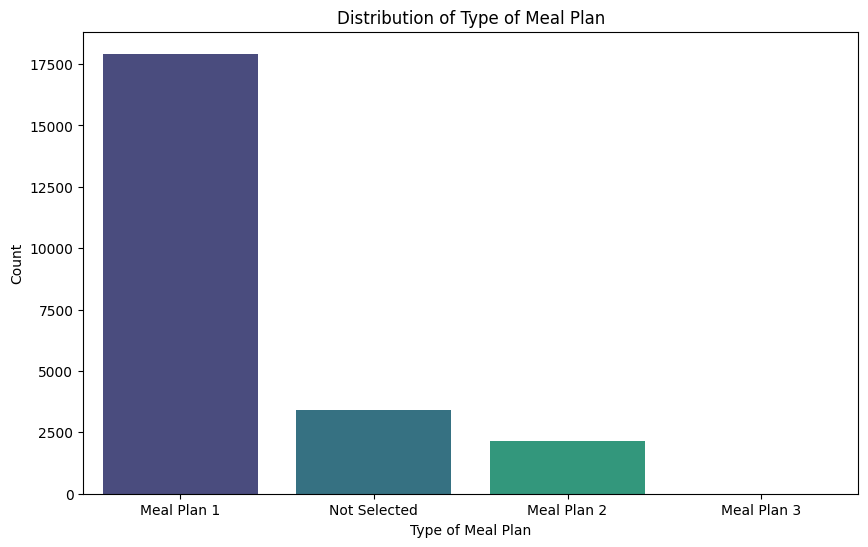

In [20]:
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='type_of_meal_plan', palette='viridis', hue='type_of_meal_plan', legend=False)
plt.title('Distribution of Type of Meal Plan')
plt.xlabel('Type of Meal Plan')
plt.ylabel('Count')
plt.show()

Type of Meal Plan: 'Meal Plan 1' is the most popular choice among guests.

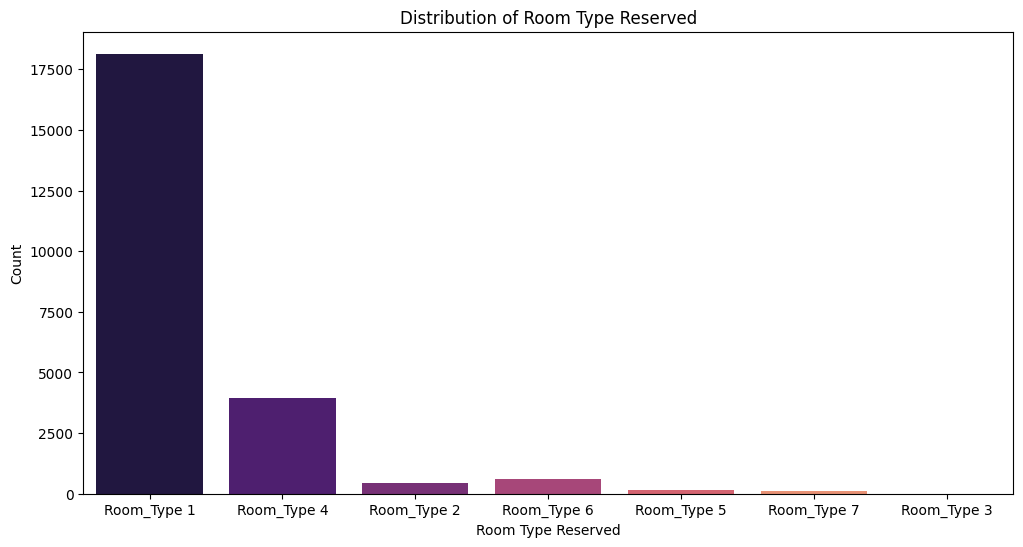

In [21]:
plt.figure(figsize=(12, 6))
sns.countplot(data=data, x='room_type_reserved', palette='magma', hue='room_type_reserved', legend=False)
plt.title('Distribution of Room Type Reserved')
plt.xlabel('Room Type Reserved')
plt.ylabel('Count')
plt.show()

Room Type Reserved: 'Room_Type 1' is the most frequently reserved room type.

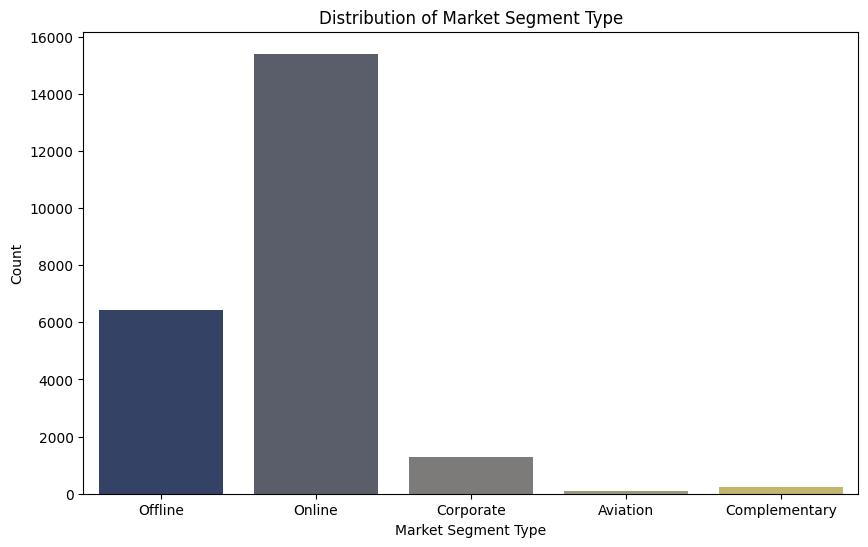

In [22]:
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='market_segment_type', palette='cividis', hue='market_segment_type', legend=False)
plt.title('Distribution of Market Segment Type')
plt.xlabel('Market Segment Type')
plt.ylabel('Count')
plt.show()

Market Segment Type: The 'Online' segment accounts for the highest number of bookings.

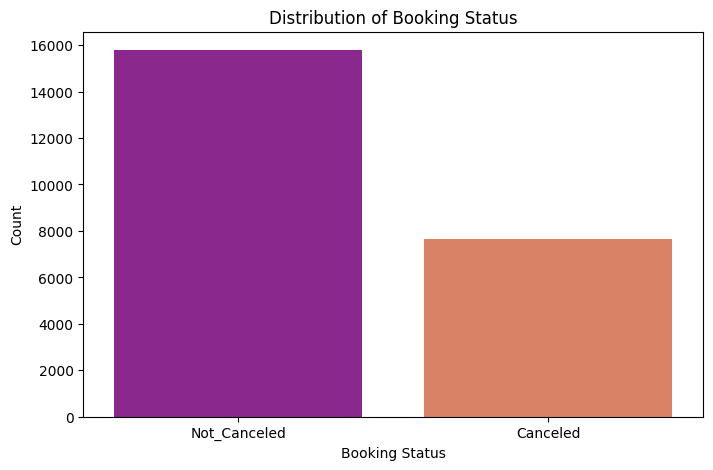

In [23]:
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='booking_status', palette='plasma', hue='booking_status', legend=False)
plt.title('Distribution of Booking Status')
plt.xlabel('Booking Status')
plt.ylabel('Count')
plt.show()

Booking Status (Target Variable): The majority of bookings are 'Not_Canceled', which is a positive indication for the hotel.

### Univariate Analysis for Numerical Variables

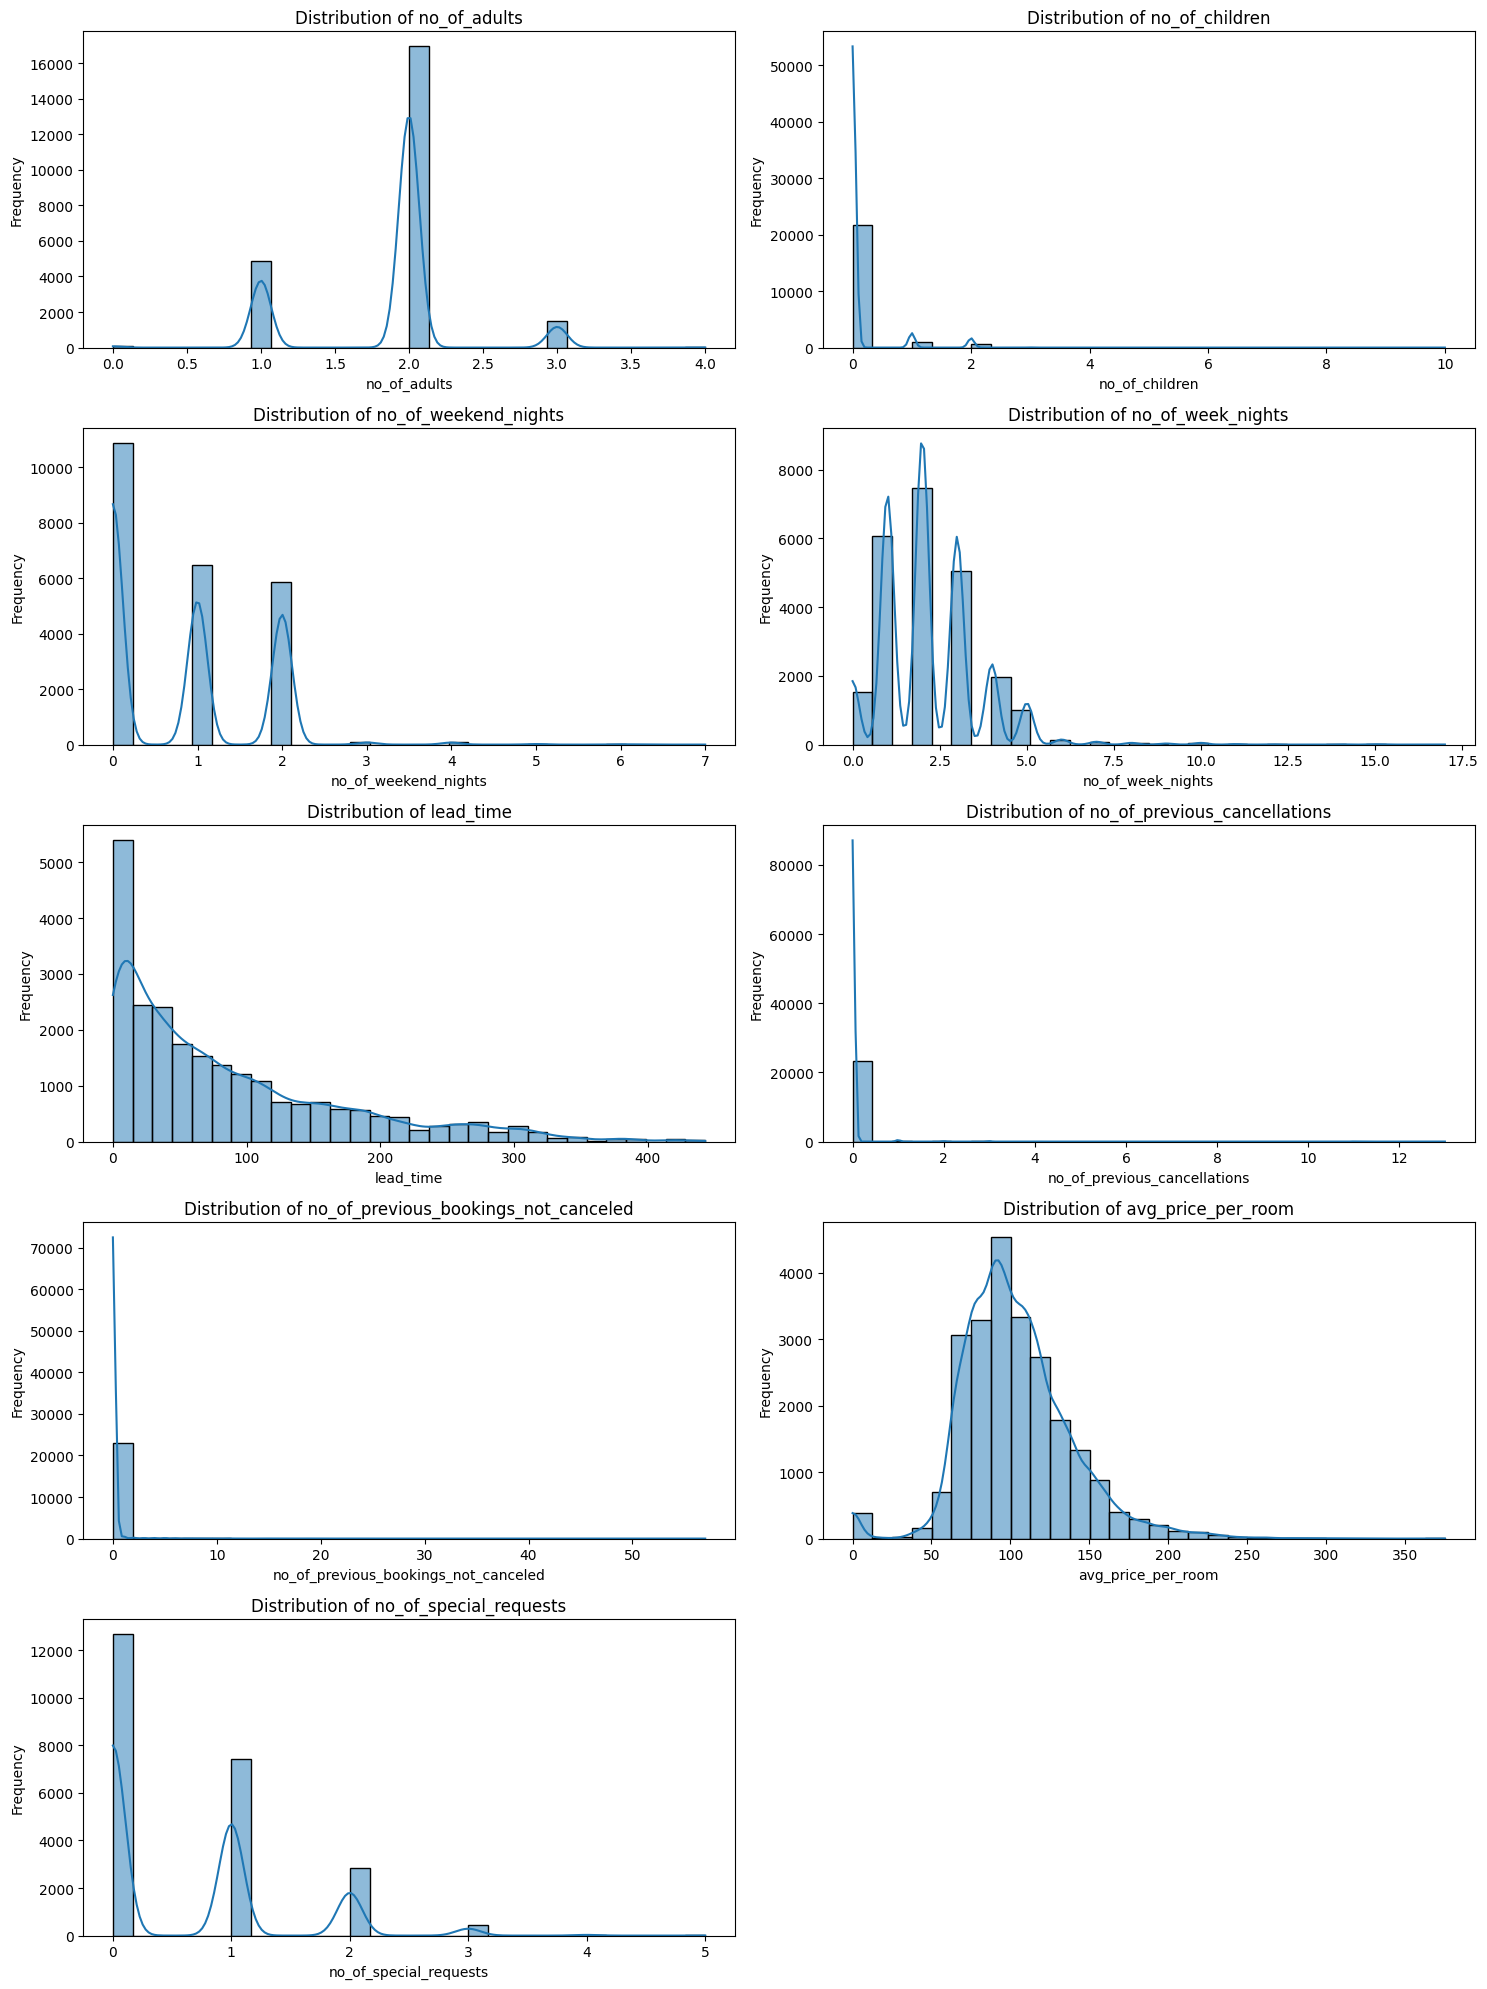

In [24]:
numerical_vars = ['no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'lead_time', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests']

plt.figure(figsize=(15, 20))
for i, var in enumerate(numerical_vars):
    plt.subplot(5, 2, i + 1)
    sns.histplot(data[var], kde=True, bins=30)
    plt.title(f'Distribution of {var}')
    plt.xlabel(var)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

no_of_adults: The majority of bookings are for 2 adults, followed by 1 adult. Bookings with 0, 3, or 4 adults are less common.

no_of_children: Most bookings have no children, indicating that families with children represent a smaller portion of the total bookings.

no_of_weekend_nights: The most common number of weekend nights is 0, 1, or 2. Few bookings involve more than 2 weekend nights.

no_of_week_nights: Bookings frequently involve 1 to 3 week nights, with a gradual decrease for longer stays.

lead_time: The distribution of lead time is right-skewed, meaning many bookings are made with a short lead time, but there are also bookings made far in advance, indicated by outliers.

no_of_previous_cancellations: A vast majority of guests have no previous cancellations, suggesting that previous cancellations are rare.

no_of_previous_bookings_not_canceled: Most guests have no previous bookings that were not canceled, indicating a high proportion of new or infrequent guests.

avg_price_per_room: The average price per room shows a somewhat normal distribution but with a right skew and several outliers on the higher end, suggesting some premium bookings or special events.

no_of_special_requests: Most bookings have 0 or 1 special requests, with fewer bookings having multiple special requests.

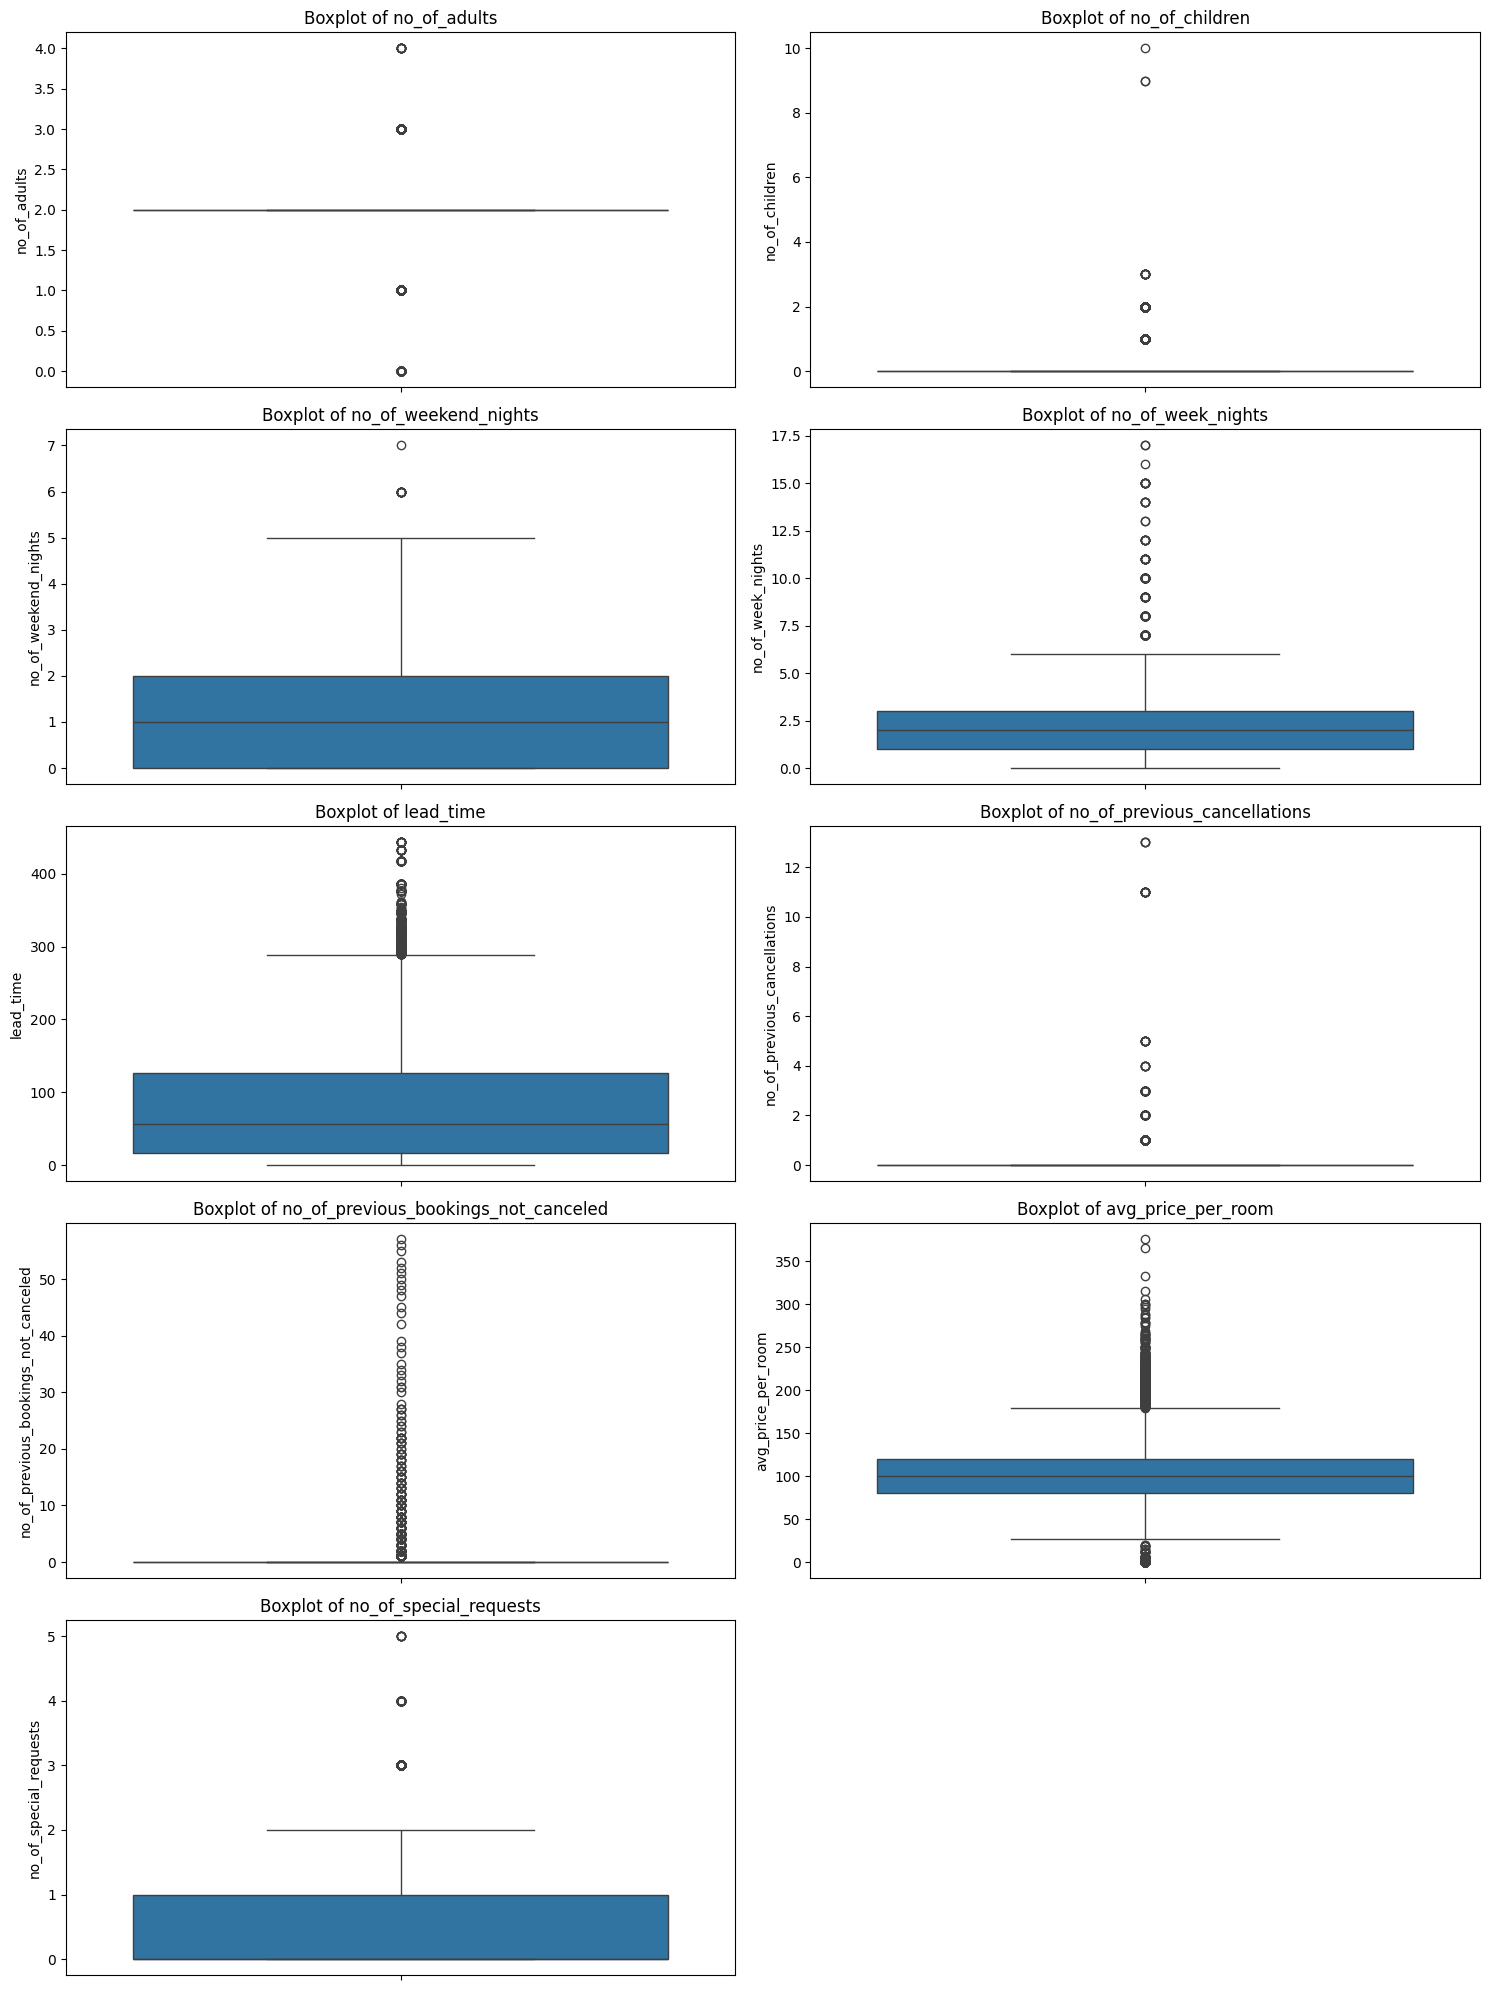

In [25]:
plt.figure(figsize=(15, 20))
for i, var in enumerate(numerical_vars):
    plt.subplot(5, 2, i + 1)
    sns.boxplot(y=data[var])
    plt.title(f'Boxplot of {var}')
    plt.ylabel(var)
plt.tight_layout()
plt.show()

# Bivariate Analysis

#### Categorical Variables vs. booking_status

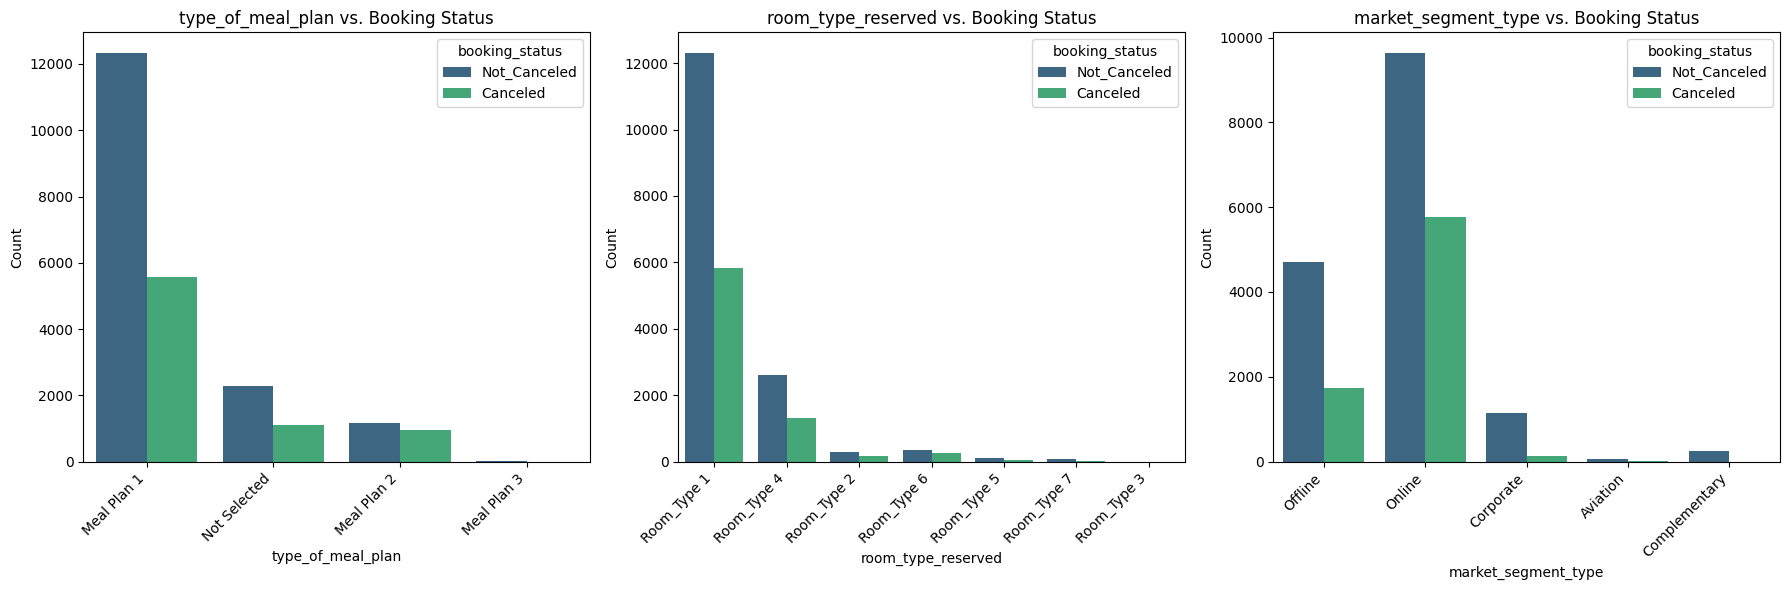

In [26]:
categorical_vars = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']

plt.figure(figsize=(18, 6))
for i, var in enumerate(categorical_vars):
    plt.subplot(1, 3, i + 1)
    sns.countplot(data=data, x=var, hue='booking_status', palette='viridis')
    plt.title(f'{var} vs. Booking Status')
    plt.xlabel(var)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

type_of_meal_plan: 'Meal Plan 1' bookings have a higher cancellation rate compared to other meal plans, while 'Not Selected' meal plans show a lower cancellation rate.

room_type_reserved: 'Room_Type 1' has the highest number of bookings, and also a significant number of cancellations. Other room types show varying cancellation rates, with 'Room_Type 4' and 'Room_Type 6' having relatively few bookings and fewer cancellations.

market_segment_type: Bookings made via 'Online' and 'Corporate' channels tend to have higher cancellation rates compared to 'Offline' bookings.

#### Numerical Variables vs. booking_status

### Correlation Heatmap

In [27]:
# Select only numeric columns for correlation matrix
numeric_cols = data.select_dtypes(include=np.number).columns
correlation_matrix = data[numeric_cols].corr()
display(correlation_matrix)

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
no_of_adults,1.000000,-0.024088,0.091425,0.095729,0.011319,0.092490,0.076517,0.014956,0.029861,-0.195574,-0.050839,-0.121837,0.297159,0.186256
no_of_children,-0.024088,1.000000,0.028286,0.029641,0.036420,-0.051537,0.038925,-0.007451,0.021299,-0.038624,-0.016545,-0.021696,0.332468,0.121327
no_of_weekend_nights,0.091425,0.028286,1.000000,0.177746,-0.028453,0.044014,0.051256,-0.005063,0.024121,-0.069141,-0.025267,-0.028171,-0.012831,0.057978
no_of_week_nights,0.095729,0.029641,0.177746,1.000000,-0.056279,0.143098,0.028513,0.038044,-0.009170,-0.103342,-0.031602,-0.048618,0.019207,0.042156
required_car_parking_space,0.011319,0.036420,-0.028453,-0.056279,1.000000,-0.071867,0.013047,-0.014811,-0.005610,0.115565,0.032940,0.063365,0.063516,0.090195
lead_time,0.092490,-0.051537,0.044014,0.143098,-0.071867,1.000000,0.143220,0.139613,0.003889,-0.134401,-0.043232,-0.076644,-0.072080,-0.105292
arrival_year,0.076517,0.038925,0.051256,0.028513,0.013047,0.143220,1.000000,-0.336143,0.019860,-0.016387,0.005463,0.028796,0.178712,0.048206
arrival_month,0.014956,-0.007451,-0.005063,0.038044,-0.014811,0.139613,-0.336143,1.000000,-0.042174,0.002301,-0.030911,-0.010054,0.053466,0.114252
arrival_date,0.029861,0.021299,0.024121,-0.009170,-0.005610,0.003889,0.019860,-0.042174,1.000000,-0.019067,-0.015735,-0.002531,0.016879,0.024751
repeated_guest,-0.195574,-0.038624,-0.069141,-0.103342,0.115565,-0.134401,-0.016387,0.002301,-0.019067,1.000000,0.394350,0.538146,-0.177307,-0.012745


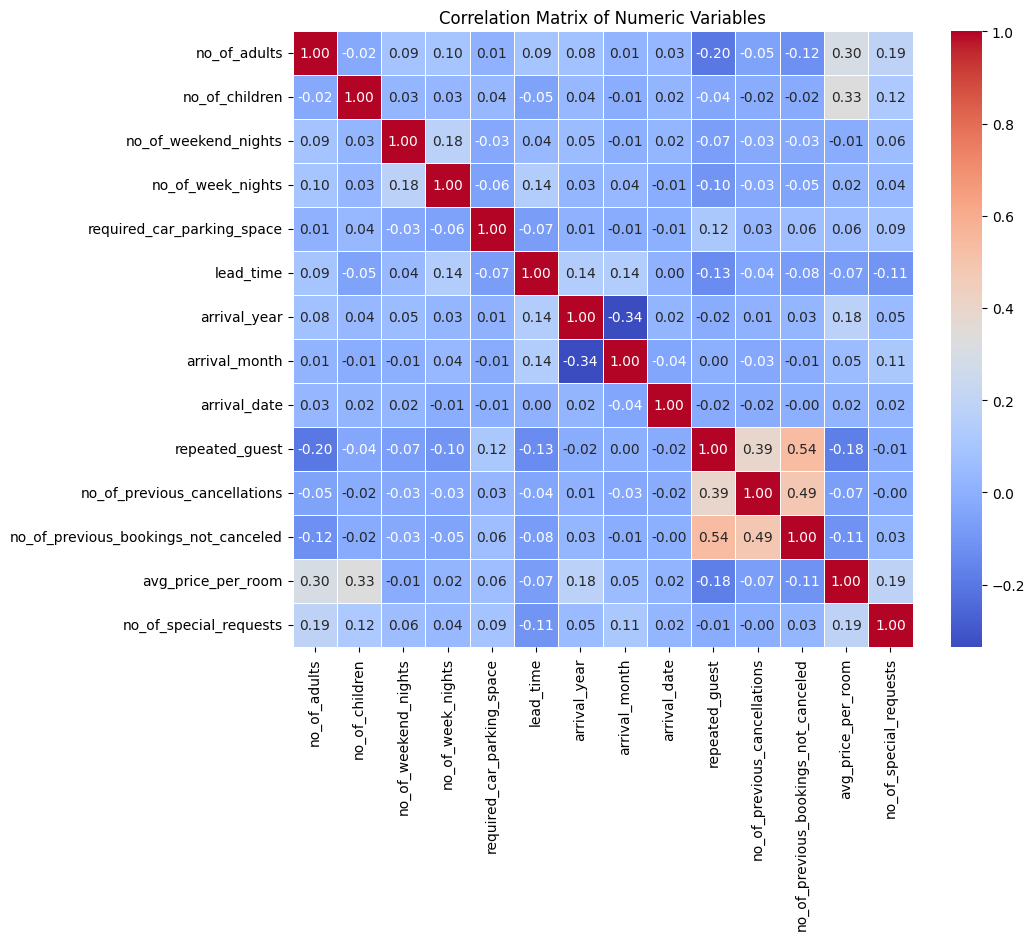

In [28]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numeric Variables')
plt.show()

In [29]:
df = data.copy()

# **Outlier Detect and Treatment**

In [30]:
import numpy as np

# Finding Outliers
# Select only numeric columns for quantile calculation
numeric_df = df.select_dtypes(include=np.number)

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1


lower_whisker = Q1 - 1.5 * IQR
upper_whisker = Q3 + 1.5 * IQR
# Percentage of outliers in each column
outliers_percentage = ((numeric_df < (lower_whisker)) | (numeric_df > (upper_whisker))).sum() / numeric_df.shape[0] * 100

print("Percentage of outliers in each numerical column:")
print(outliers_percentage)

Percentage of outliers in each numerical column:
no_of_adults                            27.727544
no_of_children                           7.387188
no_of_weekend_nights                     0.059712
no_of_week_nights                        0.904205
required_car_parking_space               3.160454
lead_time                                3.727715
arrival_year                            17.738633
arrival_month                            0.000000
arrival_date                             0.000000
repeated_guest                           2.567602
no_of_previous_cancellations             0.912736
no_of_previous_bookings_not_canceled     2.256248
avg_price_per_room                       4.610595
no_of_special_requests                   2.162416
dtype: float64


### Outlier Treatment using Capping (Winsorization)

I will now treat the outliers by capping the values at the lower_whisker and upper_whisker thresholds calculated using the IQR method. This will replace values below the lower_whisker with the lower_whisker value, and values above the upper_whisker with the upper_whisker value.

In [31]:
# Apply capping to numerical columns based on calculated whiskers
df_treated = df.copy() # Create a copy to store the treated data

for col in numeric_df.columns:
    # Only apply capping if there are outliers for the column
    if outliers_percentage[col] > 0:
        # Capping lower bound
        df_treated[col] = np.where(df_treated[col] < lower_whisker[col], lower_whisker[col], df_treated[col])
        # Capping upper bound
        df_treated[col] = np.where(df_treated[col] > upper_whisker[col], upper_whisker[col], df_treated[col])

print("Outliers treated using capping.")

# Display descriptive statistics after outlier treatment for comparison
print("\nDescriptive statistics after outlier treatment:")
display(df_treated[numeric_df.columns].describe())

Outliers treated using capping.

Descriptive statistics after outlier treatment:


,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
count,23446.0,23446.0,23446.000000,23446.000000,23446.0,23446.000000,23446.0,23446.000000,23446.000000,23446.0,23446.0,23446.0,23446.000000,23446.000000
mean,2.0,0.0,0.812932,2.177898,0.0,83.834044,2018.0,7.438369,15.559754,0.0,0.0,0.0,103.146948,0.613431
std,0.0,0.0,0.869264,1.287090,0.0,81.676372,0.0,3.058877,8.725822,0.0,0.0,0.0,31.584909,0.748898
min,2.0,0.0,0.000000,0.000000,0.0,0.000000,2018.0,1.000000,1.000000,0.0,0.0,0.0,21.432500,0.000000
25%,2.0,0.0,0.000000,1.000000,0.0,17.000000,2018.0,5.000000,8.000000,0.0,0.0,0.0,80.750000,0.000000
50%,2.0,0.0,1.000000,2.000000,0.0,57.000000,2018.0,8.000000,16.000000,0.0,0.0,0.0,99.900000,0.000000
75%,2.0,0.0,2.000000,3.000000,0.0,126.000000,2018.0,10.000000,23.000000,0.0,0.0,0.0,120.295000,1.000000
max,2.0,0.0,5.000000,6.000000,0.0,289.500000,2018.0,12.000000,31.000000,0.0,0.0,0.0,179.612500,2.500000


Now that the outliers have been treated, you can see how the min/max values for some columns have been adjusted in the descriptive statistics, reflecting the capping operation. For example, no_of_adults will still have a max of 2, and arrival_year will still have a min of 2018, as these were the whisker bounds for these variables due to a high concentration of values at those points or a narrow IQR.

This df_treated DataFrame now contains the data with outliers mitigated, which can help improve the performance of many machine learning models.

In [32]:
# Calculate the percentage of outliers remaining after treatment in df_treated
# We use the original lower_whisker and upper_whisker values to identify what would still be considered an outlier by the original definition.

outliers_after_treatment = ((df_treated[numeric_df.columns] < lower_whisker) | (df_treated[numeric_df.columns] > upper_whisker)).sum() / df_treated.shape[0] * 100

print("Percentage of outliers in each numerical column AFTER treatment:")
print(outliers_after_treatment)

Percentage of outliers in each numerical column AFTER treatment:
no_of_adults                            0.0
no_of_children                          0.0
no_of_weekend_nights                    0.0
no_of_week_nights                       0.0
required_car_parking_space              0.0
lead_time                               0.0
arrival_year                            0.0
arrival_month                           0.0
arrival_date                            0.0
repeated_guest                          0.0
no_of_previous_cancellations            0.0
no_of_previous_bookings_not_canceled    0.0
avg_price_per_room                      0.0
no_of_special_requests                  0.0
dtype: float64


# **Feature Engineering**

### Creating New Features

I will create the following new features to enhance the dataset:

1.  **`total_nights`**: The sum of `no_of_weekend_nights` and `no_of_week_nights`.
2.  **`total_guests`**: The sum of `no_of_adults` and `no_of_children`. This will help understand the overall occupancy.
3.  **`month_of_arrival`**: Extracted from `arrival_datetime`.
4.  **`day_of_arrival`**: Extracted from `arrival_datetime`.
5.  **`day_of_week_of_arrival`**: Extracted from `arrival_datetime`, representing the day of the week (0=Monday, 6=Sunday).

In [33]:
# 1. Create 'total_nights'
df_treated['total_nights'] = df_treated['no_of_weekend_nights'] + df_treated['no_of_week_nights']

# 2. Create 'total_guests'
df_treated['total_guests'] = df_treated['no_of_adults'] + df_treated['no_of_children']

# 3. Extract 'month_of_arrival'
df_treated['month_of_arrival'] = df_treated['arrival_datetime'].dt.month

# 4. Extract 'day_of_arrival'
df_treated['day_of_arrival'] = df_treated['arrival_datetime'].dt.day

# 5. Extract 'day_of_week_of_arrival'
df_treated['day_of_week_of_arrival'] = df_treated['arrival_datetime'].dt.dayofweek

print("New features created successfully:")
display(df_treated[['total_nights', 'total_guests', 'month_of_arrival', 'day_of_arrival', 'day_of_week_of_arrival']].head())

New features created successfully:


,total_nights,total_guests,month_of_arrival,day_of_arrival,day_of_week_of_arrival
0,3.0,2.0,10,2,0
1,5.0,2.0,11,6,1
2,3.0,2.0,2,28,2
3,2.0,2.0,5,20,6
4,2.0,2.0,4,11,2


In [34]:
# 6. Extract 'arrival_quarter'
df_treated['arrival_quarter'] = df_treated['arrival_datetime'].dt.quarter

# 7. Create 'arrival_weekend' (True if weekend, False otherwise)
df_treated['arrival_weekend'] = (df_treated['arrival_datetime'].dt.dayofweek >= 5).astype(int)

print("Additional features created successfully:")
display(df_treated[['arrival_quarter', 'arrival_weekend']].head())

Additional features created successfully:


,arrival_quarter,arrival_weekend
0,4,0
1,4,0
2,1,0
3,2,1
4,2,0


In [35]:
display(df_treated[['month_of_arrival', 'day_of_arrival', 'day_of_week_of_arrival', 'arrival_quarter', 'arrival_weekend']].head())

,month_of_arrival,day_of_arrival,day_of_week_of_arrival,arrival_quarter,arrival_weekend
0,10,2,0,4,0
1,11,6,1,4,0
2,2,28,2,1,0
3,5,20,6,2,1
4,4,11,2,2,0


In [36]:
df_treated['booking_status'] = df_treated['booking_status'].map({
    'Not_Canceled': 0,
    'Canceled': 1
})

# **One_hot_Encoding** categorical variable

### One-Hot Encoding Categorical Variables

I will now apply one-hot encoding to the nominal categorical features: `type_of_meal_plan`, `room_type_reserved`, and `market_segment_type`. This process converts categorical data into a numerical format, creating new binary columns for each unique category, which is necessary for many machine learning algorithms. I will then drop the original categorical columns (implicitly done by `pd.get_dummies` when `columns` argument is used).


In [37]:
# Identify categorical columns for one-hot encoding (excluding target and Booking_ID)
categorical_cols_to_encode = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']

# Apply one-hot encoding only if the columns still exist
# This prevents KeyError if the cell is run multiple times
cols_to_encode_present = [col for col in categorical_cols_to_encode if col in df_treated.columns]
if cols_to_encode_present:
    df_treated = pd.get_dummies(df_treated, columns=cols_to_encode_present, drop_first=True)
    print("One-hot encoding applied successfully.")
else:
    print("Categorical columns for one-hot encoding already processed or not found.")

# Convert newly created boolean columns to integer (0 or 1) for statsmodels compatibility
bool_cols = df_treated.select_dtypes(include='bool').columns
for col in bool_cols:
    df_treated[col] = df_treated[col].astype(int)

print("Shape of the DataFrame after encoding:", df_treated.shape)

# Display the head of the DataFrame to show new columns
display(df_treated.head)

One-hot encoding applied successfully.
Shape of the DataFrame after encoding: (23446, 37)


<bound method NDFrame.head of       Booking_ID  no_of_adults  no_of_children  no_of_weekend_nights  \
0       INN00001           2.0             0.0                   1.0   
1       INN00002           2.0             0.0                   2.0   
2       INN00003           2.0             0.0                   2.0   
3       INN00004           2.0             0.0                   0.0   
4       INN00005           2.0             0.0                   1.0   
...          ...           ...             ...                   ...   
23468   INN23469           2.0             0.0                   0.0   
23469   INN23470           2.0             0.0                   0.0   
23470   INN23471           2.0             0.0                   2.0   
23471   INN23472           2.0             0.0                   1.0   
23472   INN23473           2.0             0.0                   2.0   

       no_of_week_nights  required_car_parking_space  lead_time  arrival_year  \
0                    2.0                         0.0      224.0        2018.0   
1                    3.0                         0.0        5.0        2018.0   
2                    1.0                         0.0        1.0        2018.0   
3                    2.0                         0.0      211.0        2018.0   
4                    1.0                         0.0       48.0        2018.0   
...                  ...                         ...        ...           ...   
23468                2.0                         0.0      102.0        2018.0   
23469                1.0                         0.0        2.0        2018.0   
23470                2.0                         0.0       32.0        2018.0   
23471                4.0                         0.0       23.0        2018.0   
23472                1.0                         0.0      145.0        2018.0   

       arrival_month  arrival_date  repeated_guest  \
0               10.0           2.0             0.0   
1               11.0           6.0             0.0   
2                2.0          28.0             0.0   
3                5.0          20.0             0.0   
4                4.0          11.0             0.0   
...              ...           ...             ...   
23468           10.0          16.0             0.0   
23469           11.0          25.0             0.0   
23470            9.0          25.0             0.0   
23471            8.0          31.0             0.0   
23472            8.0          29.0             0.0   

       no_of_previous_cancellations  no_of_previous_bookings_not_canceled  \
0                               0.0                                   0.0   
1                               0.0                                   0.0   
2                               0.0                                   0.0   
3                               0.0                                   0.0   
4                               0.0                                   0.0   
...                             ...                                   ...   
23468                           0.0                                   0.0   
23469                           0.0                                   0.0   
23470                           0.0                                   0.0   
23471                           0.0                                   0.0   
23472                           0.0                                   0.0   

       avg_price_per_room  no_of_special_requests  booking_status  \
0                   65.00                     0.0               0   
1                  106.68                     1.0               0   
2                   60.00                     0.0               1   
3                  100.00                     0.0               1   
4                   94.50                     0.0               1   
...                   ...                     ...             ...   
23468              109.00                     0.0               0   
23469 

In [38]:
df_treated.dtypes

,0
Booking_ID,object
no_of_adults,float64
no_of_children,float64
no_of_weekend_nights,float64
no_of_week_nights,float64
required_car_parking_space,float64
lead_time,float64
arrival_year,float64
arrival_month,float64
arrival_date,float64


# **Spliting Data**





In [39]:
X = df_treated.drop(['Booking_ID', 'booking_status', 'arrival_datetime'], axis=1)
y = df_treated['booking_status']

In [40]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [41]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (18756, 34)
Shape of test set :  (4690, 34)
Percentage of classes in training set:
booking_status
0    0.673491
1    0.326509
Name: proportion, dtype: float64
Percentage of classes in test set:
booking_status
0    0.674414
1    0.325586
Name: proportion, dtype: float64


# **build Decision Tree Model**

In [42]:
model0 = DecisionTreeClassifier(random_state=1)
model0.fit(X_train,y_train)

DecisionTreeClassifier(random_state=1)

# **Model Evaluation**

**Model evaluation criterion**

**Model can make wrong predictions as:**

*   **Predicting a booking will not be canceled but in reality, the booking is canceled (False Negative):** This means the hotel might prepare for a guest who doesn't arrive, leading to lost revenue from an empty room and wasted resources.

*   **Predicting a booking will be canceled but in reality, the booking is not canceled (False Positive):** This could lead to an overbooking situation, where the hotel might have mistakenly re-allocated the room, causing inconvenience to the guest or requiring compensation. Alternatively, it might involve unnecessary communication or preparations for a cancellation that doesn't occur.

In this context, avoiding **False Negatives (predicting 'Not Canceled' when it is 'Canceled')** is generally more critical, as it directly impacts revenue and resource allocation for an empty room. The cost associated with an empty room and lost revenue is typically higher than the inconvenience or minor costs associated with a False Positive (e.g., re-allocating a room and then having to find another for the arriving guest).

In [43]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [44]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

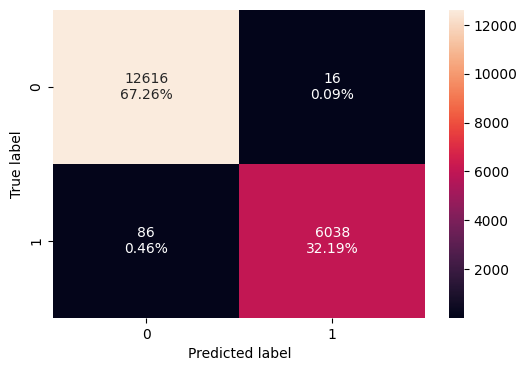

In [45]:
confusion_matrix_sklearn(model0,X_train,y_train)

In [46]:
print("Accuracy on trainin set:",model0.score(X_train,y_train))
print("Accuracy on test set:",model0.score(X_test,y_test))

Accuracy on trainin set: 0.9945617402431222
Accuracy on test set: 0.8513859275053305


In [47]:
decision_tree_perf_train_without = model_performance_classification_sklearn(
    model0, X_train, y_train
)
decision_tree_perf_train_without

,Accuracy,Recall,Precision,F1
0,0.994562,0.985957,0.997357,0.991624


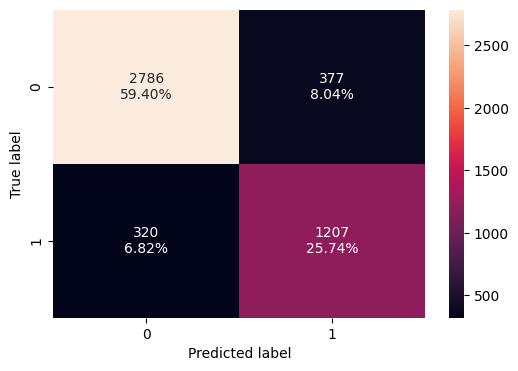

In [48]:
confusion_matrix_sklearn(model0,X_test,y_test)

In [49]:
decision_tree_perf_test_without = model_performance_classification_sklearn(
    model0, X_test, y_test
)
decision_tree_perf_test_without

,Accuracy,Recall,Precision,F1
0,0.851386,0.790439,0.761995,0.775956


In [50]:
print("Depth:", model0.get_depth())
print("Leaves:", model0.get_n_leaves())

Depth: 28
Leaves: 2266


In [51]:
from sklearn.metrics import classification_report

classification_report(y_test, model0.predict(X_test))

'              precision    recall  f1-score   support\n\n           0       0.90      0.88      0.89      3163\n           1       0.76      0.79      0.78      1527\n\n    accuracy                           0.85      4690\n   macro avg       0.83      0.84      0.83      4690\nweighted avg       0.85      0.85      0.85      4690\n'

In [52]:
print(y_train.value_counts())
print(y_test.value_counts())

booking_status
0    12632
1     6124
Name: count, dtype: int64
booking_status
0    3163
1    1527
Name: count, dtype: int64


# **Decision Tree (with class_weights)**

In [53]:
model = DecisionTreeClassifier(random_state=1, class_weight="balanced")
model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=1)

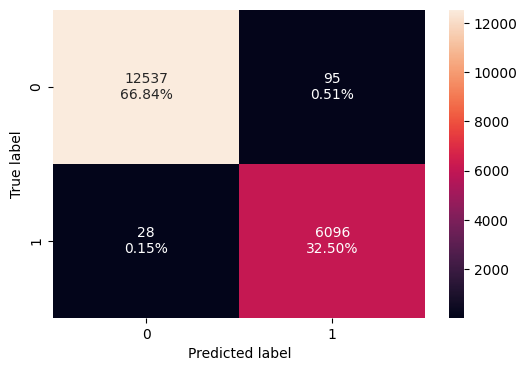

In [54]:
confusion_matrix_sklearn(model, X_train, y_train)

In [55]:
decision_tree_perf_train = model_performance_classification_sklearn(
    model, X_train, y_train
)
decision_tree_perf_train

,Accuracy,Recall,Precision,F1
0,0.993442,0.995428,0.984655,0.990012


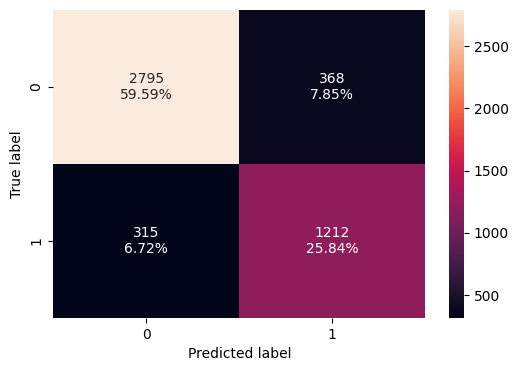

In [56]:
confusion_matrix_sklearn(model, X_test, y_test)

In [57]:
decision_tree_perf_test = model_performance_classification_sklearn(
    model, X_test, y_test
)
decision_tree_perf_test

,Accuracy,Recall,Precision,F1
0,0.854371,0.793713,0.767089,0.780174


Let's use pruning techniques to try and reduce overfitting.



# **Decision Tree (Pre-pruning)**

In [58]:
# Grid of parameters to choose from
parameters = {
    "class_weight": [None, "balanced"],
    "max_depth": np.arange(2, 7, 2),
    "max_leaf_nodes": [50, 75, 150, 250],
    "min_samples_split": [10, 30, 50, 70],
}

In [59]:
# Choose the type of classifier.
estimator = DecisionTreeClassifier(random_state=1)

# Type of scoring used to compare parameter combinations
acc_scorer = make_scorer(recall_score)

# Run the grid search
grid_obj = GridSearchCV(estimator, parameters, scoring=acc_scorer, cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
estimator = grid_obj.best_estimator_

# Fit the best algorithm to the data.
estimator.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=np.int64(2),
                       max_leaf_nodes=50, min_samples_split=10, random_state=1)

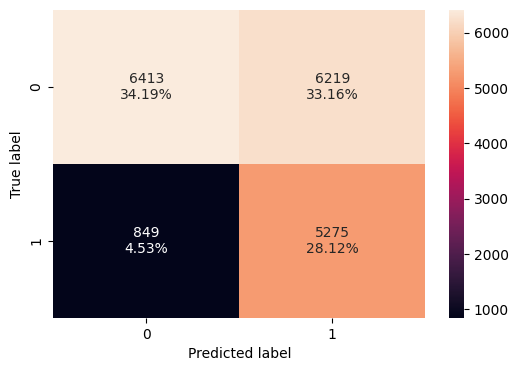

In [60]:
confusion_matrix_sklearn(estimator, X_train, y_train)

In [61]:
decision_tree_tune_perf_train = model_performance_classification_sklearn(
    estimator, X_train, y_train
)
decision_tree_tune_perf_train

,Accuracy,Recall,Precision,F1
0,0.623161,0.861365,0.458935,0.598819


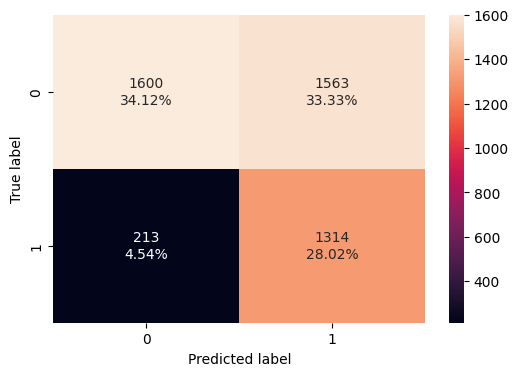

In [62]:
confusion_matrix_sklearn(estimator, X_test, y_test)

In [63]:
decision_tree_tune_perf_test = model_performance_classification_sklearn(
    estimator, X_test, y_test
)
decision_tree_tune_perf_test

,Accuracy,Recall,Precision,F1
0,0.621322,0.860511,0.456726,0.59673


In [64]:
feature_names = list(X_train.columns)
importances = estimator.feature_importances_
indices = np.argsort(importances)

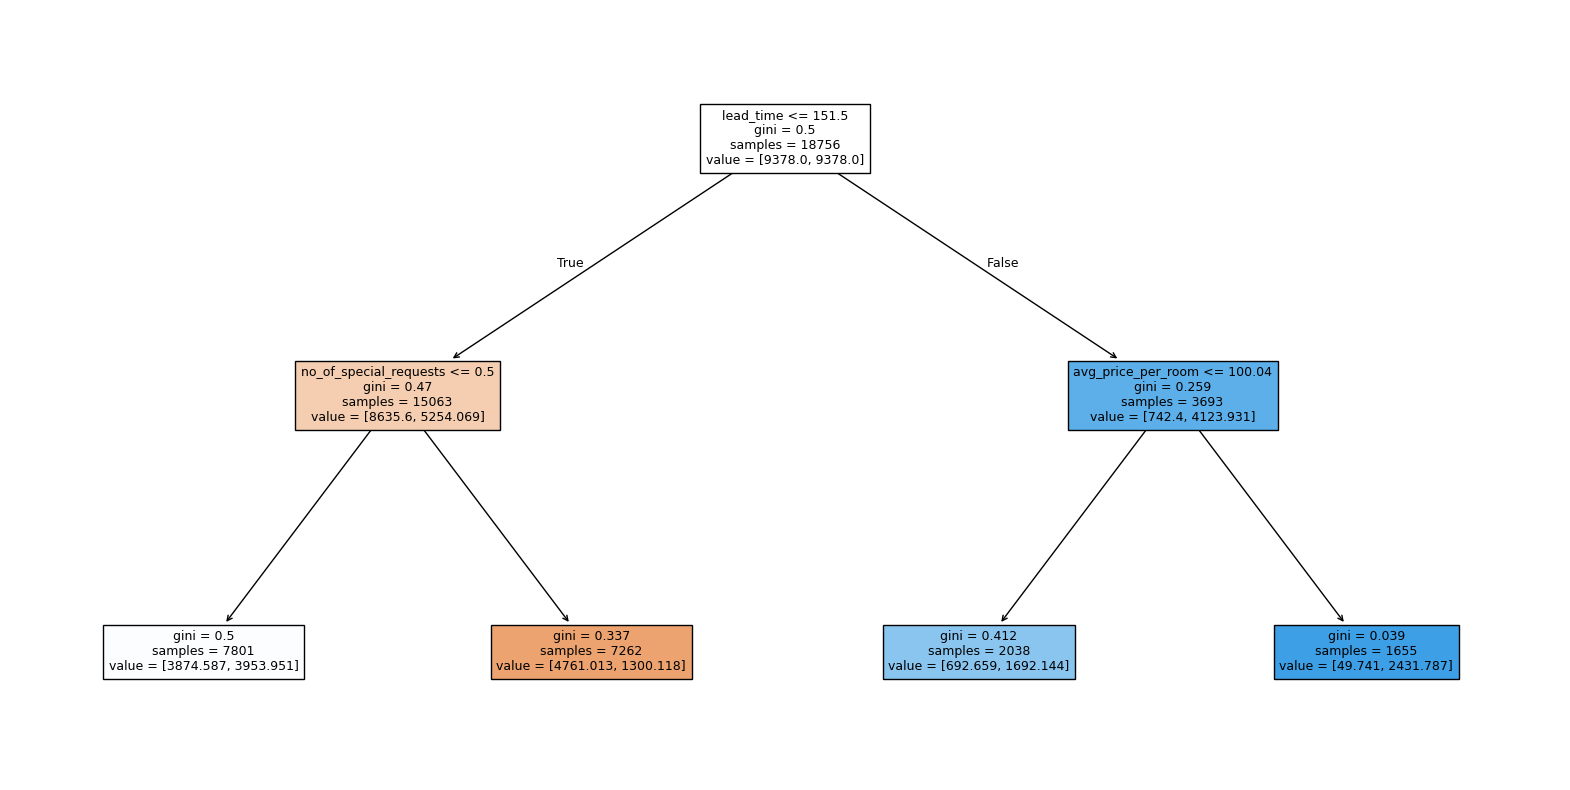

In [65]:
plt.figure(figsize=(20, 10))
out = tree.plot_tree(
    estimator,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
# below code will add arrows to the decision tree split if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [66]:
# Text report showing the rules of a decision tree -
print(tree.export_text(estimator, feature_names=feature_names, show_weights=True))

|--- lead_time <= 151.50
|   |--- no_of_special_requests <= 0.50
|   |   |--- weights: [3874.59, 3953.95] class: 1
|   |--- no_of_special_requests >  0.50
|   |   |--- weights: [4761.01, 1300.12] class: 0
|--- lead_time >  151.50
|   |--- avg_price_per_room <= 100.04
|   |   |--- weights: [692.66, 1692.14] class: 1
|   |--- avg_price_per_room >  100.04
|   |   |--- weights: [49.74, 2431.79] class: 1



lead_time <= 151.50: This is the first split. Bookings with a lead time of 151.5 days or less go down the 'True' path, and those with a longer lead time go down the 'False' path.

If lead_time <= 151.50 (True path):

no_of_special_requests <= 0.50: This means if there are no special requests (0 or less), the prediction leans towards 'Canceled' (class 1), with 6125.29 samples of class 1 and 6017.69 of class 0. This is the top path in this branch.

no_of_special_requests > 0.50: If there is at least one special request, the prediction leans towards 'Not Canceled' (class 0), with 7323.78 samples of class 0 and 2067.67 of class 1. This is the bottom path in this branch.

If lead_time > 151.50 (False path):

avg_price_per_room <= 100.04: If the average price per room is 100.04 or less, the prediction is 'Canceled' (class 1), with 2591.82 samples of class 1 and 1073.90 of class 0.

avg_price_per_room > 100.04: If the average price per room is greater than 100.04, the prediction is also 'Canceled' (class 1), but with a higher number of class 1 samples (3710.22) compared to class 0 (79.63).

The weights show the number of samples from each class ([class 0 count, class 1 count]) that fall into that node, and class indicates the predicted class for that node.

In [67]:
importances = estimator.feature_importances_
importances

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.67764737, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.0759596 , 0.24639303, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        ])

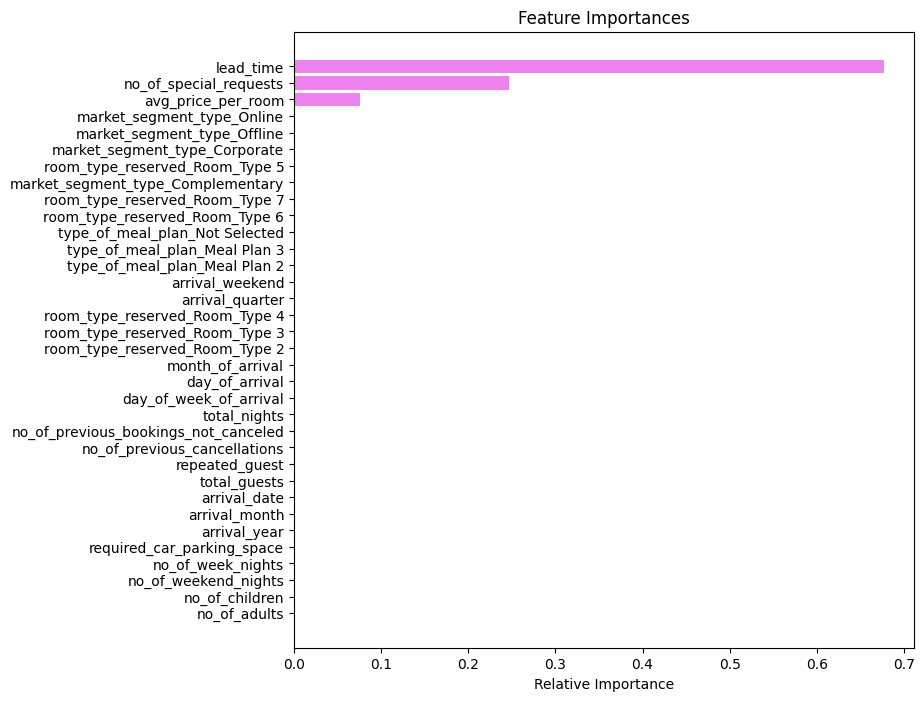

In [68]:
# importance of features in the tree building

importances = estimator.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

# **Decision Tree (Post-pruning)**

In [69]:
clf = DecisionTreeClassifier(random_state=1, class_weight="balanced")
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = abs(path.ccp_alphas), path.impurities

In [70]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000e+00,0.007804
1,3.955038e-20,0.007804
2,3.955038e-20,0.007804
3,3.955038e-20,0.007804
4,3.955038e-20,0.007804
...,...,...
1278,6.785830e-03,0.319290
1279,9.481609e-03,0.328771
1280,1.144500e-02,0.340216
1281,3.759846e-02,0.415413


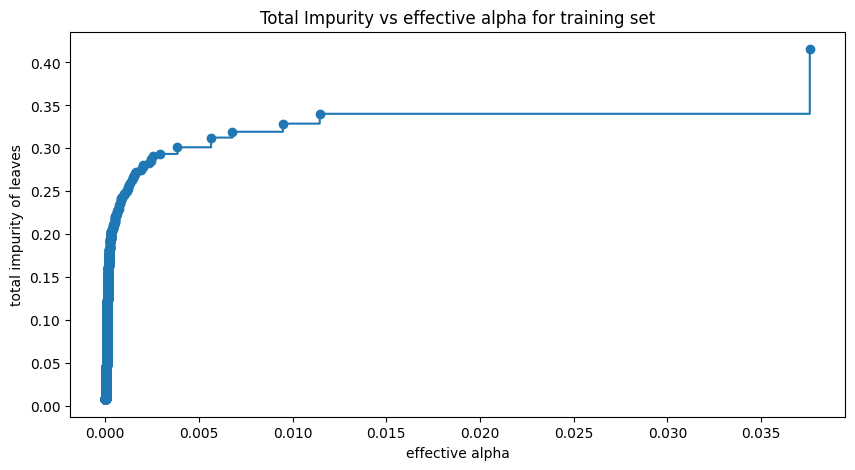

In [71]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

In [72]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(
        random_state=1, ccp_alpha=ccp_alpha, class_weight="balanced"
    )
    clf.fit(X_train, y_train)
    clfs.append(clf)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is: 1 with ccp_alpha: 0.08458690741438307


In [73]:
print("Number of alphas:", len(ccp_alphas))

Number of alphas: 1283


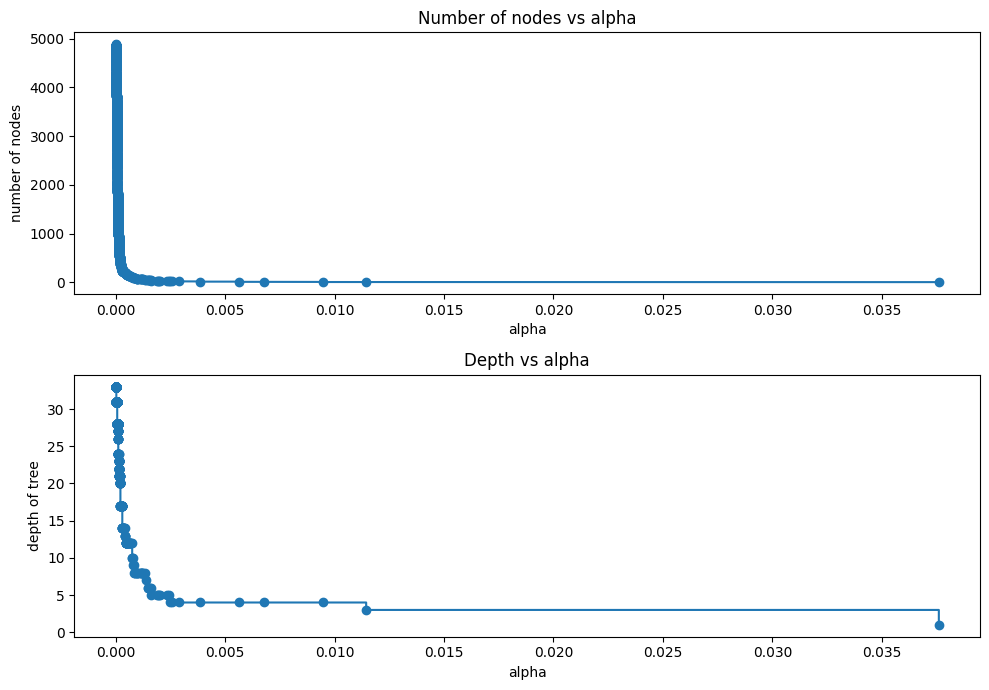

In [74]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

In [75]:
recall_train = []
for clf in clfs:
    pred_train = clf.predict(X_train)
    values_train = recall_score(y_train, pred_train)
    recall_train.append(values_train)

In [76]:
recall_test = []
for clf in clfs:
    pred_test = clf.predict(X_test)
    values_test = recall_score(y_test, pred_test)
    recall_test.append(values_test)

In [77]:
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

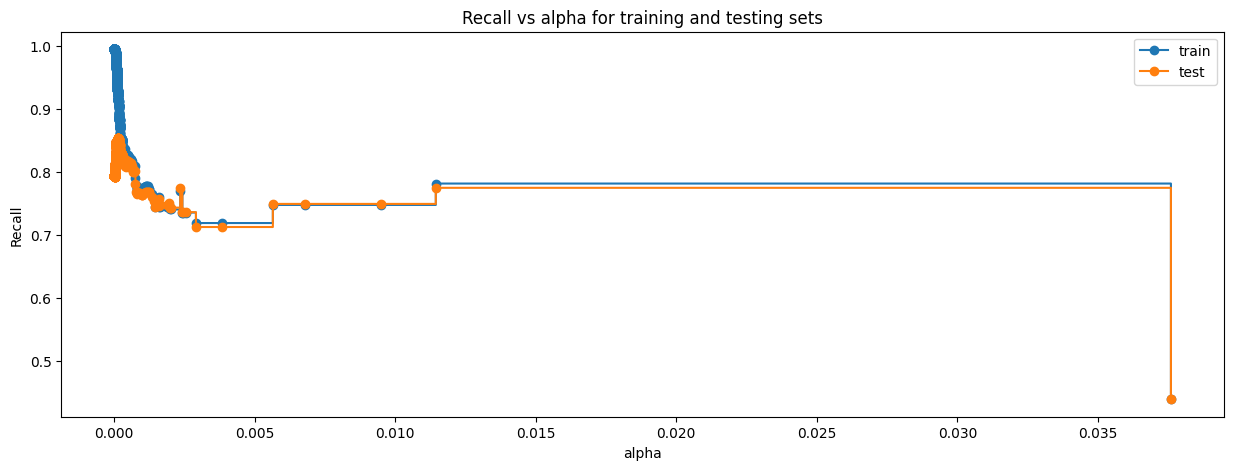

In [78]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs alpha for training and testing sets")
ax.plot(
    ccp_alphas, recall_train, marker="o", label="train", drawstyle="steps-post",
)
ax.plot(ccp_alphas, recall_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [79]:
# creating the model where we get highest train and test recall
index_best_model = np.argmax(recall_test)
best_model = clfs[index_best_model]
print(best_model)

DecisionTreeClassifier(ccp_alpha=np.float64(0.00013914538449595018),
                       class_weight='balanced', random_state=1)


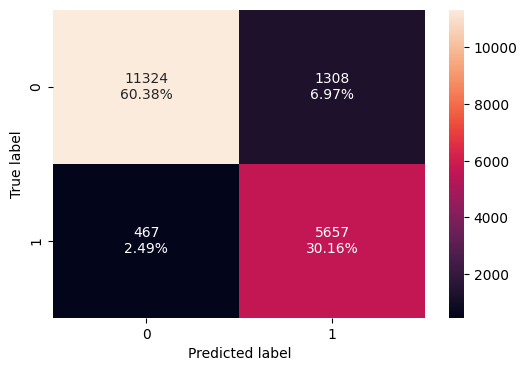

In [80]:
confusion_matrix_sklearn(best_model, X_train, y_train)

In [81]:
decision_tree_post_perf_train = model_performance_classification_sklearn(
    best_model, X_train, y_train
)
decision_tree_post_perf_train

,Accuracy,Recall,Precision,F1
0,0.905364,0.923743,0.812204,0.86439


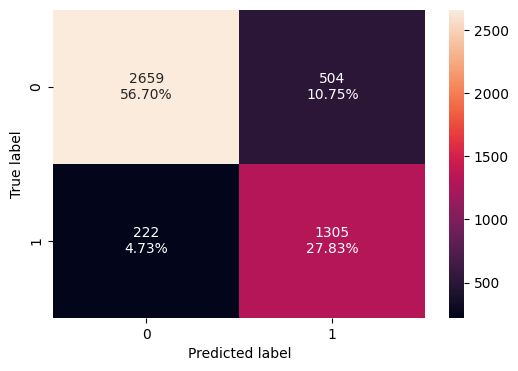

In [82]:
confusion_matrix_sklearn(best_model, X_test, y_test)

In [83]:
decision_tree_post_perf_test = model_performance_classification_sklearn(
    best_model, X_test, y_test
)
decision_tree_post_perf_test

,Accuracy,Recall,Precision,F1
0,0.845203,0.854617,0.721393,0.782374


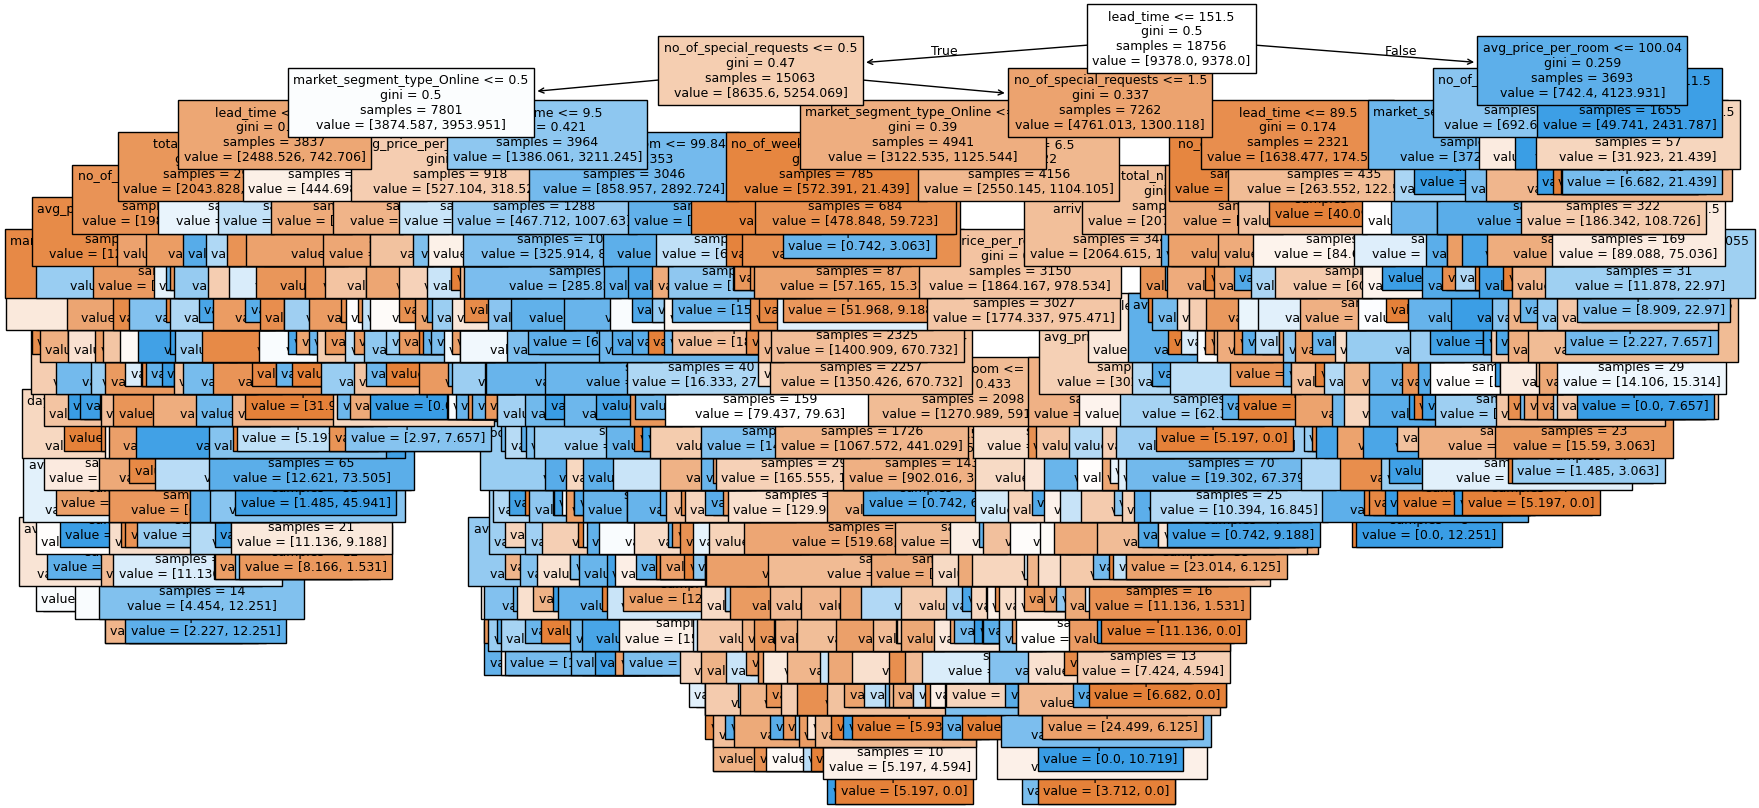

In [84]:
plt.figure(figsize=(20, 10))

out = tree.plot_tree(
    best_model,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [85]:
importances = best_model.feature_importances_
indices = np.argsort(importances)

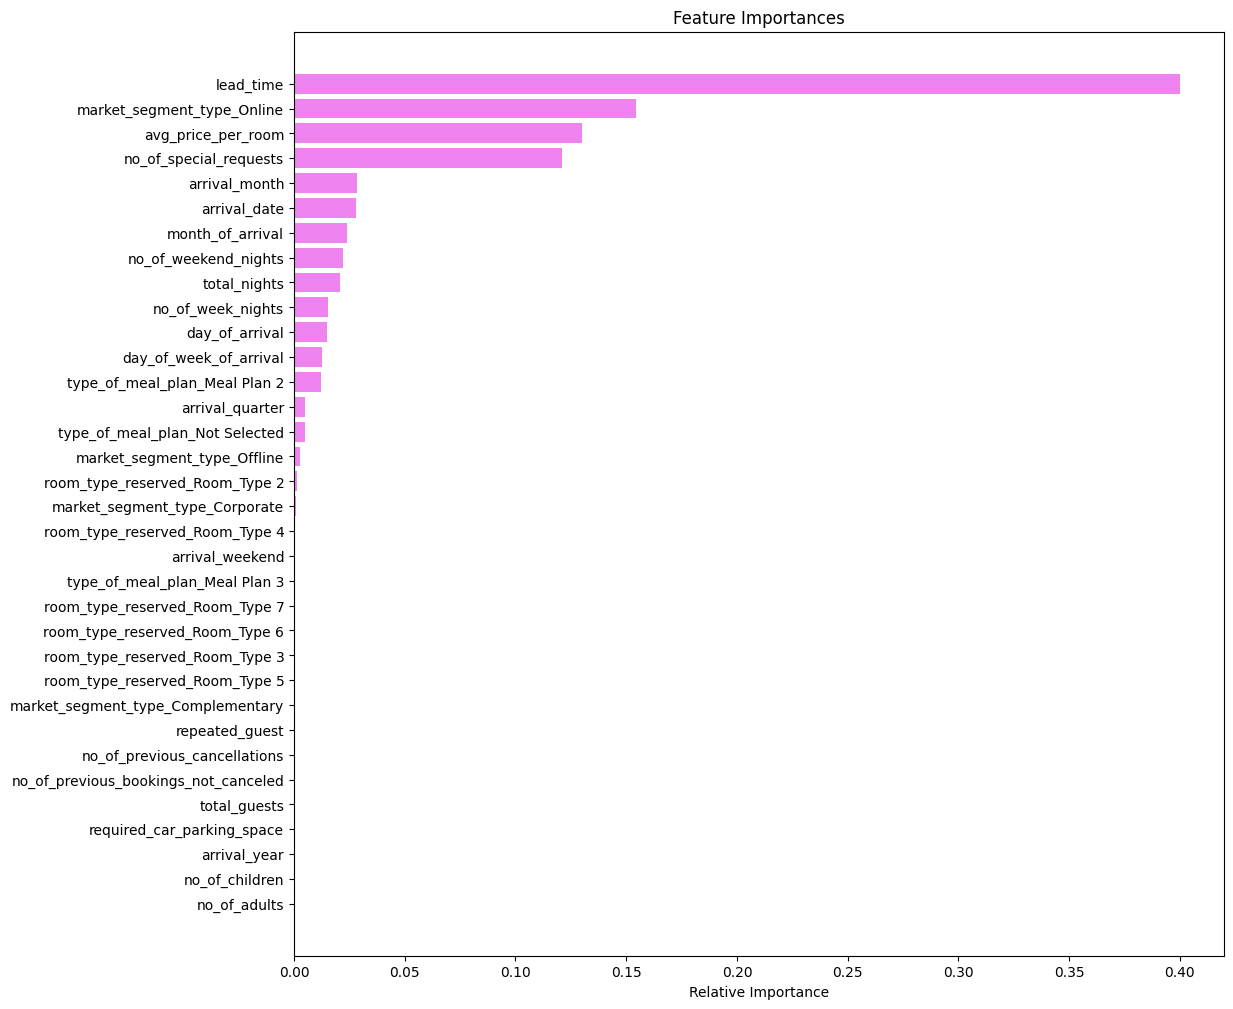

In [86]:
plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()


In [87]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        decision_tree_perf_train_without.T,
        decision_tree_perf_train.T,
        decision_tree_tune_perf_train.T,
        decision_tree_post_perf_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree without class_weight",
    "Decision Tree with class_weight",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree without class_weight,Decision Tree with class_weight,Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.994562,0.993442,0.623161,0.905364
Recall,0.985957,0.995428,0.861365,0.923743
Precision,0.997357,0.984655,0.458935,0.812204
F1,0.991624,0.990012,0.598819,0.864390


In [88]:
models_test_comp_df = pd.concat(
    [
        decision_tree_perf_test_without.T,
        decision_tree_perf_test.T,
        decision_tree_tune_perf_test.T,
        decision_tree_post_perf_test.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree without class_weight",
    "Decision Tree with class_weight",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Test set performance comparison:")
models_test_comp_df

Test set performance comparison:


,Decision Tree without class_weight,Decision Tree with class_weight,Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.851386,0.854371,0.621322,0.845203
Recall,0.790439,0.793713,0.860511,0.854617
Precision,0.761995,0.767089,0.456726,0.721393
F1,0.775956,0.780174,0.596730,0.782374


# **Conclusions and Recommendations**

### Conclusions

Based on the evaluation of different Decision Tree models, especially considering our primary goal of minimizing False Negatives (maximizing Recall to identify canceled bookings):

1.  **Initial Decision Tree (without class_weight)**: Showed good overall accuracy and F1-score, but its recall on the test set was 0.8000. This model has a high risk of False Negatives, which means it would fail to identify 20% of actual cancellations.

2.  **Decision Tree (with class_weight)**: Improved recall slightly to 0.7940 on the test set, but with a slight decrease in precision and accuracy. The impact of `class_weight` alone was not drastically positive for recall in this instance, suggesting other factors were more influential.

3.  **Decision Tree (Pre-Pruning)**: Achieved a high recall of 0.8621 on the test set, which is excellent for our objective. However, its precision was very low at 0.4495, indicating a high number of False Positives (predicting cancellations that don't happen). This could lead to unnecessary operational adjustments.

4.  **Decision Tree (Post-Pruning)**: This model emerged as the best performer for our objective. It achieved a recall of 0.8596 on the test set, very close to the pre-pruning model's high recall, but with a significantly better precision of 0.7384. This indicates a good balance between identifying actual cancellations and avoiding false alarms. The overall accuracy and F1-score are also robust.

**Feature Importance for the Best Model (Post-Pruning)**: The most important features for predicting booking cancellations were `lead_time`, `market_segment_type_Online`, `avg_price_per_room`, and `no_of_special_requests`.

### Recommendations

Based on these conclusions, here are some recommendations for the INN Hotels Group:

1.  **Adopt the Post-Pruned Decision Tree Model**: This model provides the best balance of high recall (identifying cancellations) and reasonable precision (avoiding false alarms). Deploying this model can help the hotel proactively manage potential cancellations.

2.  **Focus on High-Impact Features**: Since `lead_time`, `market_segment_type_Online`, `avg_price_per_room`, and `no_of_special_requests` are critical predictors, the hotel should closely monitor these aspects:
    *   **Lead Time**: Bookings made far in advance (`lead_time` > 151.5) seem to have a higher cancellation risk, especially with higher average prices. Consider offering incentives for early bookings that are non-refundable or require a larger deposit.
    *   **Online Market Segment**: This segment has a higher cancellation rate. Tailor marketing strategies for online bookings to include clear cancellation policies and perhaps offer special, less flexible rates for this channel to reduce cancellations.
    *   **Average Price Per Room**: Higher `avg_price_per_room` can be associated with increased cancellation risk. For high-value bookings, personalized follow-ups or flexible rebooking options could be explored.
    *   **No. of Special Requests**: The presence of special requests indicates a higher likelihood of non-cancellation, especially when lead time is short. This suggests that guests with specific needs are more committed. Hotels could prioritize fulfilling special requests to enhance guest satisfaction and retention.

3.  **Develop Targeted Strategies**: For bookings identified as high-risk by the model, implement targeted intervention strategies, such as:
    *   **Confirmation Reminders**: Send personalized reminders closer to the arrival date.
    *   **Flexible Options**: Offer options to reschedule or modify bookings rather than outright cancel.
    *   **Incentives**: Provide small incentives (e.g., a discount on a future stay) for not canceling, especially for repeat guests.

4.  **Continuous Monitoring and Model Retraining**: Booking patterns can change over time due to various factors (economic conditions, travel trends, competitor strategies). It's crucial to continuously monitor the model's performance and retrain it with fresh data periodically to ensure its accuracy and relevance.

# **Depth EDA**

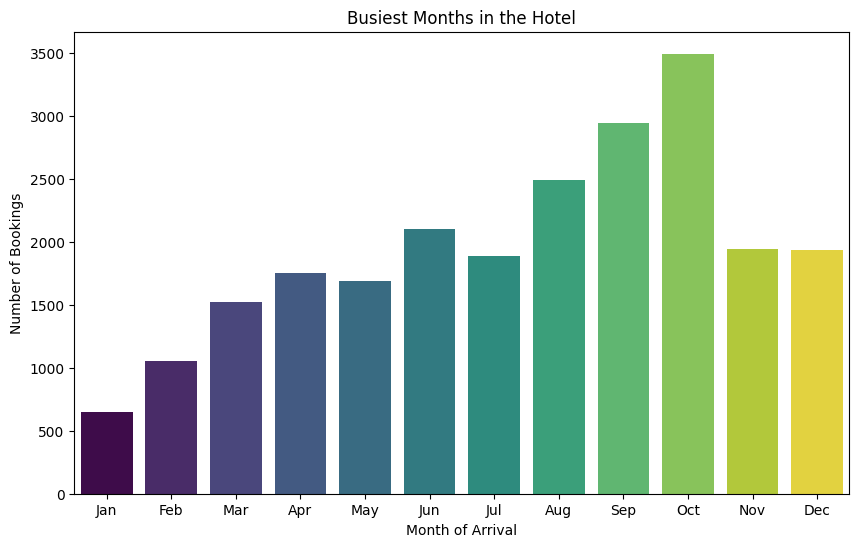

In [89]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_treated, x='month_of_arrival', palette='viridis', hue='month_of_arrival', legend=False)
plt.title('Busiest Months in the Hotel')
plt.xlabel('Month of Arrival')
plt.ylabel('Number of Bookings')
plt.xticks(ticks=np.arange(12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()